# SQA / PIMC Portfolio Optimiser
**12 assets · 24 spins · discrete weights {0, 1, 2, 3}**

Simulated Quantum Annealing (path-integral Monte Carlo) for mean–variance portfolio selection with a budget constraint.

---

## The problem

Allocate integer weights $w_a \in \{0,1,2,3\}$ to 12 assets to minimise

$$
C(w) = \lambda \, w^{\top} \Sigma w - \mu^{\top} w + P \left( \sum_a w_a - K \right)^2
$$

| Symbol | Meaning |
|--------|---------|
| $\mu$ | Expected returns |
| $\Sigma$ | Covariance matrix |
| $\lambda$ | Risk aversion (0.5) |
| $K$ | Target total weight (12) |
| $P$ | Budget penalty (4) |

Each asset uses 2 bits, so there are **24 binary variables**.  
Search space size: $2^{24} \approx 16.8$ million.  
Brute force is still feasible and is used as ground truth.

---

## Annealing parameters (not part of the financial cost)

The objective we care about is purely classical:

$$
C(w) = \lambda\, w^{\top}\Sigma w - \mu^{\top} w + P\bigl(\sum_a w_a - K\bigr)^2
$$

This is mapped **exactly** onto an Ising Hamiltonian:

$$
H_{\mathrm{classical}}(s) = \sum_{i<j} J_{ij}\, s_i s_j + \sum_i h_i s_i
$$

Here $J$ and $h$ come only from $C(w)$. They do **not** depend on the annealing schedules.

To search this landscape, SQA uses a quantum Ising model with a transverse field $\Gamma$, then applies the Suzuki–Trotter map. The result is an **effective classical** Hamiltonian on $M$ replicas:

$$
H_{\mathrm{eff}}
=
\frac{1}{M}\sum_{m=1}^{M} H_{\mathrm{classical}}\bigl(s^{(m)}\bigr)
\;-\;
J_{\perp}\sum_{i=1}^{N}\sum_{m=1}^{M}
s_{i}^{(m)}\, s_{i}^{(m+1)}
$$

with the inter-replica coupling

$$
J_{\perp}(\Gamma,\beta)
=
\frac{1}{2\beta}\ln\coth\Bigl(\frac{\beta\Gamma}{M}\Bigr)
$$

| Symbol | Appears in $C(w)$? | Role |
|--------|--------------------|------|
| $J, h$ | Indirectly (Ising form of $C$) | Classical portfolio interactions |
| $\Gamma$ | No | Transverse field → strength of tunneling |
| $\beta$ | No | Inverse temperature → how strongly low energy is preferred |
| $J_{\perp}$ | No | Coupling between Trotter replicas; depends on $\Gamma$ and $\beta$ |

**Why we change $\beta$ and $\Gamma$**

- Early: large $\Gamma$, small $\beta$ → strong tunneling, free exploration  
- Late: $\Gamma \to 0$, large $\beta$ → quantum term vanishes, system freezes into a low-energy classical state of $H_{\mathrm{classical}}$ (i.e. of $C(w)$)

So $\beta$ and $\Gamma$ control the *search dynamics*.  
The quantity we finally report is always the true financial cost $C(w)$.

---

## Pipeline

1. Build an exact **QUBO** from the financial cost  
2. Map QUBO → **Ising** Hamiltonian $(J, h)$  
3. Scale energies by `COST_SCALE = 1000`  
4. Apply Suzuki–Trotter → $M = 16$ coupled replicas  
5. Anneal three schedules together:
   - transverse field $\Gamma$ decreases  
   - inverse temperature $\beta$ increases  
   - penalty $P$ increases  
6. Monte Carlo updates (single-spin flips + budget-preserving swaps)  
7. Keep the best classical portfolio seen (**elitism**)  
8. Final classical quench ($\Gamma \approx 0$, high $\beta$)  
9. Compare with brute-force optimum over several seeds  

---

## Design choices that matter

**Energy scaling**  
Raw portfolio costs are small. Without scaling, Metropolis acceptance becomes either random or frozen.  
Multiplying the Hamiltonian by 1000 puts $\beta$ and $\Gamma$ in a usable range.

**Annealed $\beta$**  
A fixed temperature never locks into a low-energy state.  
$\beta$ rises geometrically from hot (0.1) to cold (10).

**Smart swaps (25% of moves)**  
Single-bit flips often break the budget and are rejected.  
Swapping the *same significance bit* between two assets keeps total weight unchanged, so the move is not blocked by the penalty.

**Elitism + best-slice readout**  
Every Trotter slice is scored with the true financial cost $C(w)$.  
The best portfolio seen at any time is stored and returned.

**Energy recompute when the Hamiltonian changes**  
Inside a sweep, energy is updated incrementally ($\Delta E$).  
When the penalty (and therefore $J, h$) changes, energy is fully recomputed once so Metropolis stays correct.

---

## Main functions

| Function | Role |
|----------|------|
| `binary_to_weights` | Decode bits → integer portfolio $w$ |
| `build_qubo` / `qubo_to_ising` | Exact classical → Ising mapping |
| `delta_energy_local_numba` | Local energy change for one spin flip |
| `mc_sweep_numba` | One full sweep (single flips + smart swaps) |
| `run_sqa` | Full anneal + quench + elitism |

---

## How to use

1. Change only the **CONFIGURATION** block for a new size or density.  
2. Always keep the QUBO verification cell — if it fails, stop.  
3. For $N > 24$, drop brute force and rely on multi-seed best-of-$k$.  
4. Set `CONNECTIVITY = "sparse"` to study sparse covariances.

---

## Current result

- 8 independent seeds  
- Exact ground-state success rate: **5 / 8**  
- Runtime ≈ 15–20 s per seed (with Numba)

A solid baseline for $N = 24$, ready for further scaling or real market data.

In [1]:
# ============================================================
# Complete SQA Notebook – 8-asset Portfolio (N=16)
# With β-annealing + best-slice readout + Numba acceleration
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# Numba (strongly recommended)
# ------------------------------------------------------------
try:
    from numba import njit
    NUMBA_AVAILABLE = True
    print("Numba is available – inner loops will be fast.")
except ImportError:
    NUMBA_AVAILABLE = False
    print("Numba not found – install with: pip install numba")
    print("Running in pure Python (much slower).")
    def njit(f):
        return f

np.set_printoptions(precision=4, suppress=True)

# ============================================================
# CONFIGURATION BLOCK (SCALED)
# ============================================================
NUM_ASSETS      = 12
BITS_PER_ASSET  = 2
N               = 24
M               = 16

COST_SCALE      = 1000.0       # <--- ADD THIS LINE HERE

GAMMA_START     = 4000.0       # <--- UPDATE TO 4000.0
GAMMA_END       = 1e-4
BETA_START      = 0.1          # <--- UPDATE TO 0.1
BETA_END        = 10.0         # <--- UPDATE TO 10.0

PENALTY_START   = 0.1
PENALTY_END     = 4.0

NUM_STEPS       = 800
SWEEPS_PER_STEP = 200
QUENCH_SWEEPS   = 1000

TARGET_WEIGHT   = 12.0
RISK_AVERSION   = 0.50
PENALTY_FINAL   = 4.0

CONNECTIVITY    = "dense"

SPARSITY        = 0.35

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Assets N_spins     : {NUM_ASSETS}  (N={N})")
print(f"Trotter slices M   : {M}")
print(f"β schedule         : {BETA_START} → {BETA_END}  (annealed)")
print(f"Γ schedule         : {GAMMA_START} → {GAMMA_END}")
print(f"Penalty schedule   : {PENALTY_START} → {PENALTY_END}")
print(f"Steps × sweeps     : {NUM_STEPS} × {SWEEPS_PER_STEP}")
print("="*60)


Numba is available – inner loops will be fast.
CONFIGURATION
Assets N_spins     : 12  (N=24)
Trotter slices M   : 16
β schedule         : 0.1 → 10.0  (annealed)
Γ schedule         : 4000.0 → 0.0001
Penalty schedule   : 0.1 → 4.0
Steps × sweeps     : 800 × 200


In [2]:
import pandas as pd

# ============================================================
# 2. Generate problem instance
# ============================================================
def generate_portfolio(n_assets, connectivity="dense", sparsity=0.35, seed=42):
    rng = np.random.default_rng(seed)
    mu = rng.uniform(0.03, 0.14, size=n_assets)
    A = rng.normal(0, 0.04, size=(n_assets, n_assets))
    Sigma = A @ A.T + np.diag(rng.uniform(0.015, 0.055, size=n_assets))
    if connectivity == "sparse":
        mask = rng.random((n_assets, n_assets)) > sparsity
        mask = np.triu(mask, 1) + np.triu(mask, 1).T
        Sigma = Sigma * mask
        ev, evec = np.linalg.eigh(Sigma)
        Sigma = evec @ np.diag(np.maximum(ev, 1e-4)) @ evec.T
    return mu, Sigma

mu, Sigma = generate_portfolio(NUM_ASSETS, CONNECTIVITY, SPARSITY)
print(f"\nProblem instance created ({CONNECTIVITY}).")

# ============================================================
# 2.5 Print Problem Statement for Benchmarking
# ============================================================
print("\n" + "="*70)
print("PROBLEM STATEMENT & ASSET UNIVERSE FOR BENCHMARKING")
print("="*70)
print(f"Total Assets (N)       : {NUM_ASSETS}")
print(f"Bits per Asset         : {BITS_PER_ASSET} (Values: 0 to {2**BITS_PER_ASSET - 1} units)")
print(f"Target Budget (K)      : {TARGET_WEIGHT} units")
print(f"Risk Aversion (gamma)  : {RISK_AVERSION}")
print(f"Budget Penalty (P)     : {PENALTY_FINAL}")
print("-" * 70)

print("OBJECTIVE FUNCTION:")
print("Minimize C(w) = gamma * (w^T * Sigma * w) - (mu^T * w) + P * (sum(w) - K)^2")
print("-" * 70)

# 1. Print Expected Returns (mu)
df_mu = pd.DataFrame({
    "Asset ID": [f"Asset_{i}" for i in range(NUM_ASSETS)],
    "Expected Return (mu)": mu
})
print("\n--- EXPECTED RETURNS (mu) ---")
print(df_mu.to_string(index=False))

# 2. Print Covariance Matrix (Sigma)
df_sigma = pd.DataFrame(
    Sigma,
    columns=[f"A{i}" for i in range(NUM_ASSETS)],
    index=[f"A{i}" for i in range(NUM_ASSETS)]
)
print("\n--- COVARIANCE MATRIX (Sigma) ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_sigma.to_string())
print("="*70)


Problem instance created (dense).

PROBLEM STATEMENT & ASSET UNIVERSE FOR BENCHMARKING
Total Assets (N)       : 12
Bits per Asset         : 2 (Values: 0 to 3 units)
Target Budget (K)      : 12.0 units
Risk Aversion (gamma)  : 0.5
Budget Penalty (P)     : 4.0
----------------------------------------------------------------------
OBJECTIVE FUNCTION:
Minimize C(w) = gamma * (w^T * Sigma * w) - (mu^T * w) + P * (sum(w) - K)^2
----------------------------------------------------------------------

--- EXPECTED RETURNS (mu) ---
Asset ID  Expected Return (mu)
 Asset_0              0.115135
 Asset_1              0.078277
 Asset_2              0.124446
 Asset_3              0.106710
 Asset_4              0.040360
 Asset_5              0.137318
 Asset_6              0.113725
 Asset_7              0.116467
 Asset_8              0.044092
 Asset_9              0.079542
Asset_10              0.070788
Asset_11              0.131944

--- COVARIANCE MATRIX (Sigma) ---
           A0        A1        A2

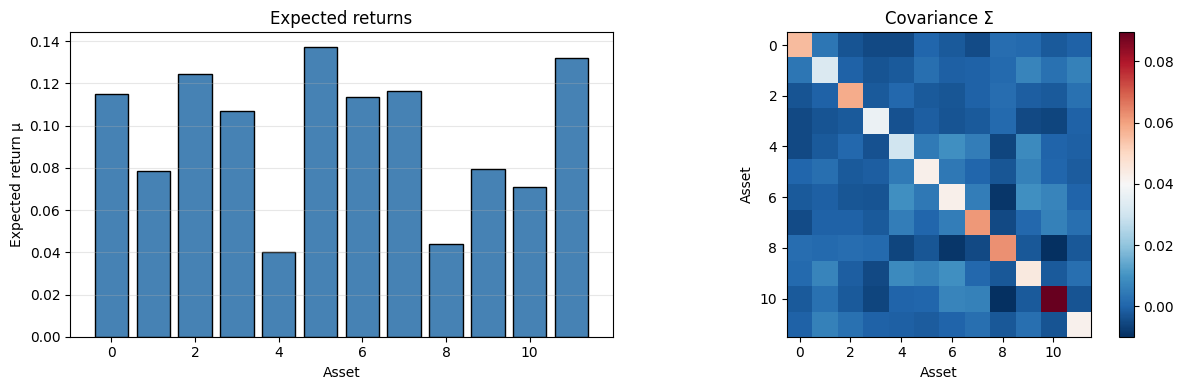

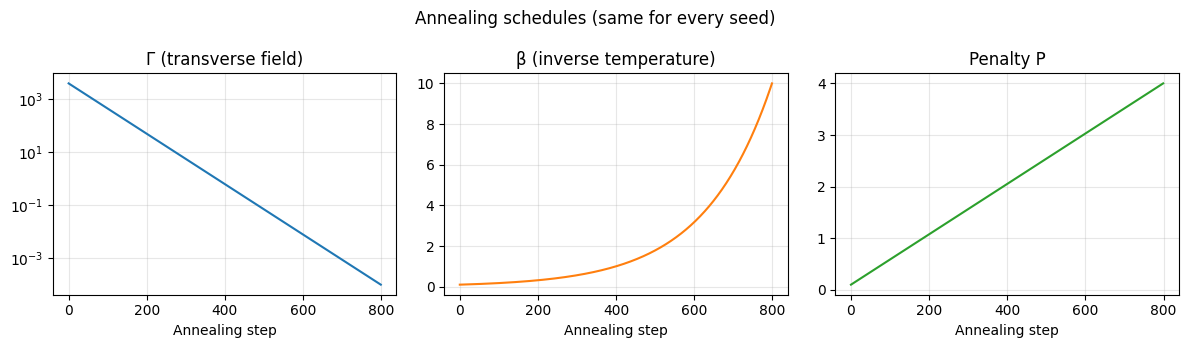

In [3]:
# ============================================================
# Plots: mu, Sigma, and annealing schedules
# ============================================================

# --- expected returns and covariance ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(np.arange(len(mu)), mu, color="steelblue", edgecolor="k")
axes[0].set_xlabel("Asset")
axes[0].set_ylabel("Expected return μ")
axes[0].set_title("Expected returns")
axes[0].grid(True, axis="y", alpha=0.3)

im = axes[1].imshow(Sigma, cmap="RdBu_r")
axes[1].set_title("Covariance Σ")
axes[1].set_xlabel("Asset")
axes[1].set_ylabel("Asset")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

# --- how beta / gamma / penalty change during one run ---
steps = np.arange(NUM_STEPS)
gamma_sched   = np.geomspace(GAMMA_START, GAMMA_END, NUM_STEPS)
beta_sched    = np.geomspace(BETA_START, BETA_END, NUM_STEPS)
penalty_sched = np.linspace(PENALTY_START, PENALTY_END, NUM_STEPS)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].plot(steps, gamma_sched)
axes[0].set_yscale("log")
axes[0].set_title("Γ (transverse field)")
axes[0].set_xlabel("Annealing step")

axes[1].plot(steps, beta_sched, color="C1")
axes[1].set_title("β (inverse temperature)")
axes[1].set_xlabel("Annealing step")

axes[2].plot(steps, penalty_sched, color="C2")
axes[2].set_title("Penalty P")
axes[2].set_xlabel("Annealing step")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle("Annealing schedules (same for every seed)")
plt.tight_layout()
plt.show()

In [4]:

# ============================================================
# 3. Mathematical helpers
# ============================================================
def binary_to_weights(bits, bits_per_asset=2):
    bits = np.asarray(bits, dtype=int)
    n = len(bits) // bits_per_asset
    w = np.zeros(n, dtype=int)
    for a in range(n):
        for b in range(bits_per_asset):
            w[a] += bits[a * bits_per_asset + b] * (2 ** b)
    return w

def build_weight_matrix(n_assets, bits_per_asset=2):
    n_bits = n_assets * bits_per_asset
    B = np.zeros((n_assets, n_bits))
    for a in range(n_assets):
        for b in range(bits_per_asset):
            B[a, a * bits_per_asset + b] = 2 ** b
    return B

def portfolio_cost(w, mu, Sigma, risk_aversion, target, penalty):
    w = np.asarray(w, dtype=float)
    return (risk_aversion * (w @ Sigma @ w)
            - mu @ w
            + penalty * (w.sum() - target) ** 2)

def build_qubo(mu, Sigma, B, risk_aversion, target, penalty):
    ones = np.ones(B.shape[0])
    Q = risk_aversion * (B.T @ Sigma @ B)
    Q += penalty * np.outer(B.T @ ones, B.T @ ones)
    linear = -(B.T @ mu) - 2 * penalty * target * (B.T @ ones)
    const = penalty * target ** 2
    np.fill_diagonal(Q, np.diag(Q) + linear)
    return Q, const


def qubo_to_ising(Q, const=0.0):
    n = Q.shape[0]
    J = np.zeros((n, n))
    h = np.zeros(n)
    for i in range(n):
        for j in range(i + 1, n):
            Jij = 0.25 * (Q[i, j] + Q[j, i])
            J[i, j] = J[j, i] = Jij
        h[i] = 0.5 * Q[i, i]
        for j in range(n):
            if i != j:
                h[i] += 0.25 * (Q[i, j] + Q[j, i])
    E0 = const + 0.5 * np.trace(Q)
    for i in range(n):
        for j in range(i + 1, n):
            E0 += 0.25 * (Q[i, j] + Q[j, i])
    return J, h, E0

In [5]:
# ============================================================
# 3.5. QUBO & Ising Mapping Verification
# ============================================================
print("\n" + "="*60)
print("VERIFYING QUBO MAPPING EXACTNESS")
print("="*60)

# Build the B matrix and QUBO for the current penalty
B_test = build_weight_matrix(NUM_ASSETS, BITS_PER_ASSET)
Q_test, const_test = build_qubo(mu, Sigma, B_test, RISK_AVERSION, TARGET_WEIGHT, PENALTY_FINAL)

# Test 5 completely random binary states
num_tests = 5
match_count = 0

for i in range(num_tests):
    # 1. Generate random binary array (x_i in {0, 1})
    x_test = np.random.randint(0, 2, size=N)

    # 2. Calculate true financial cost C(w)
    w_test = binary_to_weights(x_test, BITS_PER_ASSET)
    true_cost = portfolio_cost(w_test, mu, Sigma, RISK_AVERSION, TARGET_WEIGHT, PENALTY_FINAL)

    # 3. Calculate QUBO matrix cost: x^T * Q * x + const
    qubo_cost = x_test.T @ Q_test @ x_test + const_test

    # 4. Compare
    diff = abs(true_cost - qubo_cost)

    status = "OK" if diff < 1e-8 else "FAIL"
    print(f"Test {i+1}: True Cost = {true_cost:>9.6f} | QUBO Cost = {qubo_cost:>9.6f} | Diff = {diff:.2e} [{status}]")

    if diff < 1e-8:
        match_count += 1

print("-" * 60)
if match_count == num_tests:
    print("=> SUCCESS: QUBO matrix perfectly matches the financial cost function!")
else:
    print("=> FATAL ERROR: QUBO mapping is structurally incorrect.")


VERIFYING QUBO MAPPING EXACTNESS
Test 1: True Cost = 399.099302 | QUBO Cost = 399.099302 | Diff = 1.14e-13 [OK]
Test 2: True Cost = 143.222529 | QUBO Cost = 143.222529 | Diff = 8.53e-14 [OK]
Test 3: True Cost =  3.255407 | QUBO Cost =  3.255407 | Diff = 1.78e-15 [OK]
Test 4: True Cost = 35.072543 | QUBO Cost = 35.072543 | Diff = 5.68e-14 [OK]
Test 5: True Cost = -0.403352 | QUBO Cost = -0.403352 | Diff = 2.10e-14 [OK]
------------------------------------------------------------
=> SUCCESS: QUBO matrix perfectly matches the financial cost function!



N=24 (dense)
Spins              : 24
Possible couplings : 276
Non-zero couplings : 276
Density            : 1.000 (100.0%)
Sparsity           : 0.000
Max |J|            : 8.0094


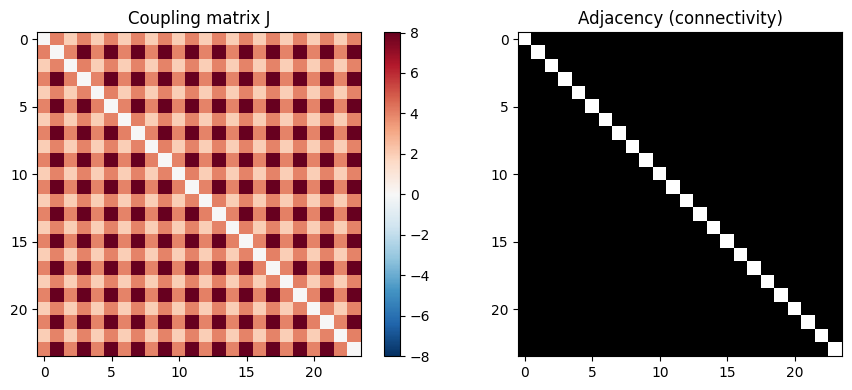

np.float64(1.0)

In [6]:

# ============================================================
# 4. Connectivity report
# ============================================================
def connectivity_report(J, title="Ising J", tol=1e-12):
    n = J.shape[0]
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    abs_c = np.abs(J[mask])
    n_possible = n * (n - 1) // 2
    n_nonzero = np.sum(abs_c > tol)
    density = n_nonzero / n_possible

    print("\n" + "="*60)
    print(title)
    print("="*60)
    print(f"Spins              : {n}")
    print(f"Possible couplings : {n_possible}")
    print(f"Non-zero couplings : {n_nonzero}")
    print(f"Density            : {density:.3f} ({density*100:.1f}%)")
    print(f"Sparsity           : {1 - density:.3f}")
    print(f"Max |J|            : {abs_c.max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    vmax = np.max(np.abs(J))
    im = axes[0].imshow(J, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[0].set_title("Coupling matrix J")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    adj = (np.abs(J) > tol).astype(int)
    np.fill_diagonal(adj, 0)
    axes[1].imshow(adj, cmap="Greys")
    axes[1].set_title("Adjacency (connectivity)")
    plt.tight_layout()
    plt.show()
    return density

B = build_weight_matrix(NUM_ASSETS, BITS_PER_ASSET)
Q_tmp, _ = build_qubo(mu, Sigma, B, RISK_AVERSION, TARGET_WEIGHT, PENALTY_FINAL)
J_tmp, _, _ = qubo_to_ising(Q_tmp)
connectivity_report(J_tmp, title=f"N={N} ({CONNECTIVITY})")


In [7]:

# ============================================================
# 5. Brute-force optimum (N=16 is still feasible)
# ============================================================
def brute_force(mu, Sigma, target):
    n_assets = len(mu)
    Nloc = n_assets * BITS_PER_ASSET
    best_c, best_b, best_w = np.inf, None, None
    for state in range(2 ** Nloc):
        bits = np.array(list(np.binary_repr(state, width=Nloc)), dtype=int)
        w = binary_to_weights(bits)
        c = portfolio_cost(w, mu, Sigma, RISK_AVERSION, target, PENALTY_FINAL)
        if c < best_c:
            best_c, best_b, best_w = c, bits.copy(), w.copy()
    return best_c, best_b, best_w

print("\nComputing brute-force optimum (this may take ~60-120 s) …")
t0 = time.perf_counter()
bf_cost, bf_bits, bf_weights = brute_force(mu, Sigma, TARGET_WEIGHT)
print(f"Brute-force cost    : {bf_cost:.6f}")
print(f"Brute-force weights : {bf_weights}")
print(f"Time                : {time.perf_counter() - t0:.1f} s")



Computing brute-force optimum (this may take ~60-120 s) …
Brute-force cost    : -0.998489
Brute-force weights : [2 0 2 2 0 2 1 1 0 0 0 2]
Time                : 618.0 s


In [11]:
# ============================================================
# 6. Numba-accelerated Monte Carlo kernels (PERFECT SWAP)
# ============================================================
@njit
def delta_energy_local_numba(replicas, J, h, J_perp, i, m, M):
    s = replicas[i, m]
    interaction = h[i]
    for j in range(replicas.shape[0]):
        if j != i:
            interaction += J[i, j] * replicas[j, m]
    dE_c = -2.0 * s * interaction / M
    dE_q = 2.0 * J_perp * s * (replicas[i, (m - 1) % M] + replicas[i, (m + 1) % M])
    return dE_c + dE_q

@njit
def mc_sweep_numba(replicas, J, h, gamma, beta, energy, M, bits_per_asset, rng_seed):
    # Lock Numba RNG for this sweep
    np.random.seed(rng_seed)

    N = replicas.shape[0]
    x = beta * gamma / M
    if x < 1e-12:
        x = 1e-12
    if x > 20.0:
        x = 20.0
    J_perp = (0.5 / beta) * np.log(1.0 / np.tanh(x))

    accepted = 0
    n_attempts = N * M
    for _ in range(n_attempts):

        # 25% budget-preserving swap
        if np.random.rand() < 0.25:
            i = np.random.randint(0, N)
            m = np.random.randint(0, M)

            bit_idx = i % bits_per_asset
            random_asset = np.random.randint(0, N // bits_per_asset)
            j = random_asset * bits_per_asset + bit_idx

            if i == j:
                continue

            s_i = replicas[i, m]
            s_j = replicas[j, m]

            if s_i != s_j:
                inter_i = h[i]
                inter_j = h[j]
                for k in range(N):
                    if k != i:
                        inter_i += J[i, k] * replicas[k, m]
                    if k != j:
                        inter_j += J[j, k] * replicas[k, m]

                dE_c_i = -2.0 * s_i * inter_i / M
                dE_c_j = -2.0 * s_j * inter_j / M
                dE_c = dE_c_i + dE_c_j + (4.0 * J[i, j] * s_i * s_j / M)

                prev_m = m - 1 if m > 0 else M - 1
                next_m = m + 1 if m < M - 1 else 0

                dE_q = (2.0 * J_perp * s_i * (replicas[i, prev_m] + replicas[i, next_m])) + \
                       (2.0 * J_perp * s_j * (replicas[j, prev_m] + replicas[j, next_m]))

                dE = dE_c + dE_q

                if dE <= 0.0 or np.random.rand() < np.exp(-beta * dE):
                    replicas[i, m] *= -1
                    replicas[j, m] *= -1
                    energy += dE
                    accepted += 1

        # 75% single-spin flip
        else:
            i = np.random.randint(0, N)
            m = np.random.randint(0, M)
            dE = delta_energy_local_numba(replicas, J, h, J_perp, i, m, M)
            if dE <= 0.0 or np.random.rand() < np.exp(-beta * dE):
                replicas[i, m] *= -1
                energy += dE
                accepted += 1

    return energy, accepted / n_attempts

In [12]:
# ============================================================
# 7. Production SQA runner WITH ELITISM & SCALING
# ============================================================

def run_sqa(mu, Sigma, target, known_optimum=None, seed=None):
    # --------------------------------------------------------
    # Reproducible initialization
    # -------------------------------------------------------
    if seed is not None:
        np.random.seed(seed)

    B = build_weight_matrix(
        NUM_ASSETS,
        BITS_PER_ASSET
    )
    # --------------------------------------------------------
    # Annealing schedules
    # --------------------------------------------------------
    gamma_sched = np.geomspace(   # Geometric decay is best for Gamma
        GAMMA_START,
        GAMMA_END,
        NUM_STEPS
    )
    beta_sched = np.geomspace(
        BETA_START,
        BETA_END,
        NUM_STEPS
    )
    penalty_sched = np.linspace(
        PENALTY_START,
        PENALTY_END,
        NUM_STEPS
    )
    # --------------------------------------------------------
    # Initial replica configuration
    # --------------------------------------------------------
    replicas = np.random.choice(
        [-1.0, 1.0],
        size=(N, M)
    )
    # --------------------------------------------------------
    # Elitism
    # --------------------------------------------------------
    elite_cost = np.inf
    elite_bits = None
    elite_weights = None
    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------
    history = []
    acceptance_history = []
    overlap_history = []

    first_hit = None
    # --------------------------------------------------------
    # Annealing
    # --------------------------------------------------------
    for step in range(NUM_STEPS):

        gamma = gamma_sched[step]
        beta = beta_sched[step]
        penalty = penalty_sched[step]
        # ----------------------------------------------------
        # Build CURRENT Hamiltonian
        # ----------------------------------------------------
        Q, const = build_qubo(
            mu,
            Sigma,
            B,
            RISK_AVERSION,
            target,
            penalty
        )

        # *** CRITICAL FIX: SCALE THE HAMILTONIAN ***
        Q *= COST_SCALE
        const *= COST_SCALE

        J, h, _ = qubo_to_ising(
            Q,
            const
        )
        # ----------------------------------------------------
        # IMPORTANT:
        # The effective Hamiltonian has changed because gamma,
        # beta, and/or penalty changed.
        #
        # Therefore reset the energy for THIS annealing step.
        # We calculate it explicitly from the current replicas.
        # ----------------------------------------------------
        x = beta * gamma / M

        if x < 1e-12:
            x = 1e-12

        if x > 20.0:
            x = 20.0

        J_perp = (
            0.5 / beta
            * np.log(1.0 / np.tanh(x))
        )
        # ----------------------------------------------------
        # Exact current effective energy
        # ----------------------------------------------------
        energy = 0.0

        # Classical part
        for m in range(M):
            s = replicas[:, m]
            classical = 0.0
            for i in range(N):
                classical -= h[i] * s[i]
                for j in range(i + 1, N):
                    classical -= (
                        J[i, j]
                        * s[i]
                        * s[j]
                    )
            energy += classical
        energy /= M
        # Quantum/Trotter part
        quantum = 0.0
        for i in range(N):
            for m in range(M):
                next_m = (m + 1) % M
                quantum -= (
                    J_perp
                    * replicas[i, m]
                    * replicas[i, next_m]
                )
        energy += quantum
        # ----------------------------------------------------
        # Monte Carlo sweeps
        # ----------------------------------------------------

        #step_acceptance = 0.0

        #for _ in range(SWEEPS_PER_STEP):

            # *** CRITICAL FIX: ADD BITS_PER_ASSET ARGUMENT ***
        #   energy, step_acceptance = mc_sweep_numba(
        #       replicas,
        #      J,
        #       h,
        #        gamma,
        #       beta,
        #      energy,
        #        M,
        #        BITS_PER_ASSET
        #   )


        step_acceptance = 0.0

        # Use the run seed as a fixed base (0 if no seed was given)
        base = 0 if seed is None else int(seed)

        # One deterministic RNG stream per (annealing step, sweep index)
        for sweep_id in range(SWEEPS_PER_STEP):
            # Mix base + step + sweep_id so the same (seed, step, sweep)
            # always draws the same random numbers inside Numba
            sweep_seed = (base + step * 100003 + sweep_id * 1009) % (2**31 - 1)

            energy, step_acceptance = mc_sweep_numba(
                replicas,
                J,
                h,
                gamma,
                beta,
                energy,
                M,
                BITS_PER_ASSET,
                sweep_seed,   # pass seed into Numba so its RNG is locked
            )

        # ----------------------------------------------------
        # Evaluate every Trotter slice using TRUE financial cost
        # ----------------------------------------------------
        slice_costs = np.empty(M)

        for m in range(M):

            bits_m = (
                (replicas[:, m] + 1) / 2
            ).astype(np.int64)

            w_m = binary_to_weights(
                bits_m,
                BITS_PER_ASSET
            )
            slice_costs[m] = portfolio_cost(
                w_m,
                mu,
                Sigma,
                RISK_AVERSION,
                target,
                PENALTY_FINAL
            )
        # ----------------------------------------------------
        # Best slice at this annealing step
        # ----------------------------------------------------
        best_m = np.argmin(
            slice_costs
        )
        cost = slice_costs[best_m]

        bits = (
            (replicas[:, best_m] + 1) / 2
        ).astype(np.int64)

        weights = binary_to_weights(
            bits,
            BITS_PER_ASSET
        )
        # ----------------------------------------------------
        # ELITISM
        # ----------------------------------------------------
        if cost < elite_cost:
            elite_cost = cost
            elite_bits = bits.copy()
            elite_weights = weights.copy()
        # ----------------------------------------------------
        # Exact ground-state hit
        # ----------------------------------------------------
        if (
            known_optimum is not None
            and first_hit is None
            and abs(cost - known_optimum) < 1e-5
        ):

            first_hit = step
        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------
        history.append(cost)
        acceptance_history.append(step_acceptance)
        # Simple replica agreement
        overlaps = []
        for m in range(1, M):

            overlaps.append(
                np.mean(
                    replicas[:, 0]
                    == replicas[:, m]
                )
            )
        overlap = np.mean(overlaps)

        overlap_history.append(
            overlap
        )
    # ========================================================
    # Classical quench
    # ========================================================
    # Rebuild Final Hamiltonian to ensure Penalty is exact
    Q, const = build_qubo(mu, Sigma, B, RISK_AVERSION, target, PENALTY_END)
    Q *= COST_SCALE
    const *= COST_SCALE
    J, h, _ = qubo_to_ising(Q, const)
    # Recalculate Quench Energy
    energy = 0.0
    for m in range(M):
        s = replicas[:, m]
        classical = 0.0
        for i in range(N):
            classical -= h[i] * s[i]
            for j in range(i + 1, N):
                classical -= (J[i, j] * s[i] * s[j])
        energy += classical / M

    b_quench = BETA_END * 2.0

    #for _ in range(QUENCH_SWEEPS):
    #    energy, acc = mc_sweep_numba(
    #        replicas,
    #        J,
    #        h,
    #        1e-8,
    #        b_quench,
    #        energy,
    #        M,
    #        BITS_PER_ASSET
    #    )

    # Same base as above so quench randomness also depends only on the run seed
    base = 0 if seed is None else int(seed)

    for q in range(QUENCH_SWEEPS):
        # Offset 10_000_000 keeps quench seeds away from anneal seeds
        quench_seed = (base + 10_000_000 + q * 1009) % (2**31 - 1)

        energy, acc = mc_sweep_numba(
            replicas,
            J,
            h,
            1e-8,
            b_quench,
            energy,
            M,
            BITS_PER_ASSET,
            quench_seed,   # lock Numba RNG for this quench sweep
        )

    # --------------------------------------------------------
    # Final slice evaluation
    # --------------------------------------------------------
    slice_costs = np.empty(M)
    for m in range(M):

        bits_m = (
            (replicas[:, m] + 1) / 2
        ).astype(np.int64)

        w_m = binary_to_weights(
            bits_m,
            BITS_PER_ASSET
        )

        slice_costs[m] = portfolio_cost(
            w_m,
            mu,
            Sigma,
            RISK_AVERSION,
            target,
            PENALTY_FINAL
        )

    best_m = np.argmin(
        slice_costs
    )
    final_cost = slice_costs[best_m]
    final_bits = (
        (replicas[:, best_m] + 1) / 2
    ).astype(np.int64)
    final_weights = binary_to_weights(
        final_bits,
        BITS_PER_ASSET
    )
    # --------------------------------------------------------
    # Final elitism update
    # --------------------------------------------------------
    if final_cost < elite_cost:

        elite_cost = final_cost

        elite_bits = final_bits.copy()

        elite_weights = final_weights.copy()

    return (
        elite_cost,
        elite_bits,
        elite_weights,
        history,
        first_hit,
        acceptance_history,
        overlap_history
    )

In [13]:
# ============================================================
# Reproducibility test (same seed twice must match)
# ============================================================
print("Running reproducibility test with seed=42 ...")

r1 = run_sqa(mu, Sigma, TARGET_WEIGHT, known_optimum=bf_cost, seed=42)
r2 = run_sqa(mu, Sigma, TARGET_WEIGHT, known_optimum=bf_cost, seed=42)

print(f"cost run1 = {r1[0]:.8f}")
print(f"cost run2 = {r2[0]:.8f}")
print("cost match:", abs(r1[0] - r2[0]) < 1e-12)
print("bits match:", np.array_equal(r1[1], r2[1]))

if abs(r1[0] - r2[0]) < 1e-12 and np.array_equal(r1[1], r2[1]):
    print("OK — this seed is reproducible. You can trust fixed gap plots.")
else:
    print("NOT OK — tell me and we add Numba-side seeding next.")

Running reproducibility test with seed=42 ...
cost run1 = -0.99436629
cost run2 = -0.99436629
cost match: True
bits match: True
OK — this seed is reproducible. You can trust fixed gap plots.


In [14]:
# ============================================================
# 8. Run several independent trials (DISPLAY FIX)
# ============================================================
print("\n" + "="*60)
print("Running SQA trials with β-annealing & Scaling")
print("="*60)

results = []
seeds = [42, 123, 999, 7, 2024, 55, 888, 314]   # 8 seeds

for i, seed in enumerate(seeds):
    print(f"\nTrial {i+1}/{len(seeds)} (seed={seed})")
    np.random.seed(seed)          # keep this
    t0 = time.perf_counter()

    cost, bits, weights, hist, hit, acc_hist, ov_hist = run_sqa(
        mu, Sigma, TARGET_WEIGHT,
        known_optimum=bf_cost,
        seed=seed
    )

    runtime = time.perf_counter() - t0

    # FIX: The cost returned is already the true financial cost
    gap = cost - bf_cost

    print(f"  Cost      : {cost:.6f}")
    print(f"  Gap to BF : {gap:.6f}")
    print(f"  Hit step  : {hit}")
    print(f"  Runtime   : {runtime:.1f} s")
    print(f"  Weights   : {weights}")

    results.append((cost, weights, runtime, hist, hit))

# ============================================================
# 9. Summary
# ============================================================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
best_idx = np.argmin([r[0] for r in results])
print(f"Best cost found   : {results[best_idx][0]:.6f}")
print(f"Brute-force cost  : {bf_cost:.6f}")
print(f"Match?            : {abs(results[best_idx][0] - bf_cost) < 1e-5}")
print(f"Best weights      : {results[best_idx][1]}")
print(f"Average runtime   : {np.mean([r[2] for r in results]):.1f} s")


Running SQA trials with β-annealing & Scaling

Trial 1/8 (seed=42)
  Cost      : -0.994366
  Gap to BF : 0.004122
  Hit step  : None
  Runtime   : 15.3 s
  Weights   : [1 1 1 2 0 2 2 1 0 0 0 2]

Trial 2/8 (seed=123)
  Cost      : -0.994366
  Gap to BF : 0.004122
  Hit step  : None
  Runtime   : 15.1 s
  Weights   : [1 1 1 2 0 2 2 1 0 0 0 2]

Trial 3/8 (seed=999)
  Cost      : -0.998489
  Gap to BF : 0.000000
  Hit step  : 242
  Runtime   : 15.8 s
  Weights   : [2 0 2 2 0 2 1 1 0 0 0 2]

Trial 4/8 (seed=7)
  Cost      : -0.998489
  Gap to BF : 0.000000
  Hit step  : 164
  Runtime   : 16.2 s
  Weights   : [2 0 2 2 0 2 1 1 0 0 0 2]

Trial 5/8 (seed=2024)
  Cost      : -0.998489
  Gap to BF : 0.000000
  Hit step  : 200
  Runtime   : 15.4 s
  Weights   : [2 0 2 2 0 2 1 1 0 0 0 2]

Trial 6/8 (seed=55)
  Cost      : -0.998489
  Gap to BF : 0.000000
  Hit step  : 237
  Runtime   : 15.1 s
  Weights   : [2 0 2 2 0 2 1 1 0 0 0 2]

Trial 7/8 (seed=888)
  Cost      : -0.998489
  Gap to BF : 0.0000

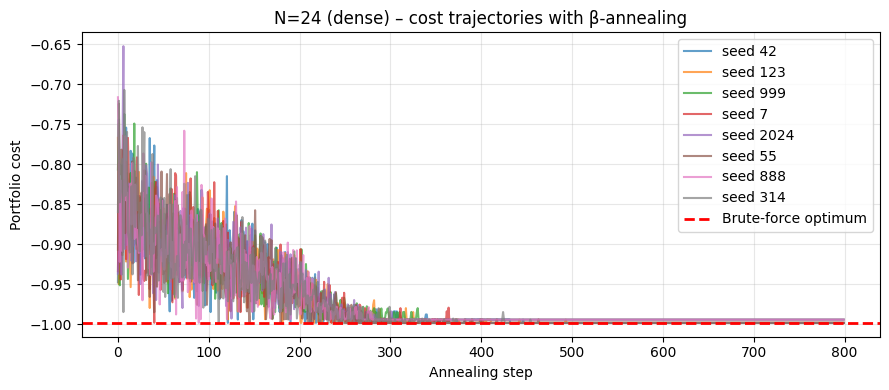


Notebook finished.


In [ ]:
# ============================================================
# 10. Cost trajectory plot
# ============================================================
plt.figure(figsize=(9, 4))
for i, r in enumerate(results):
    plt.plot(r[3], alpha=0.7, label=f"seed {seeds[i]}")
plt.axhline(bf_cost, color="red", ls="--", lw=2, label="Brute-force optimum")
plt.xlabel("Annealing step")
plt.ylabel("Portfolio cost")
plt.title(f"N={N} ({CONNECTIVITY}) – cost trajectories with β-annealing")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNotebook finished.")

In [15]:
successes = sum(1 for r in results if abs(r[0] - bf_cost) < 1e-5)
print(f"Success rate: {successes}/{len(results)}")

Success rate: 6/8


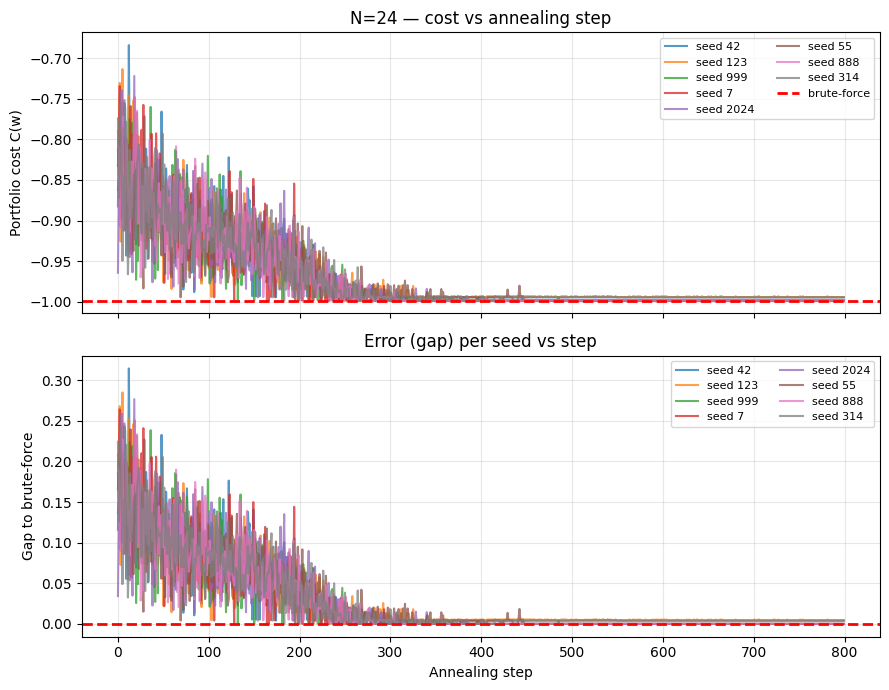

In [16]:
# ============================================================
# Cost + gap trajectories (stable once seeds are reproducible)
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for i, r in enumerate(results):
    hist = np.asarray(r[3])   # cost vs annealing step for this seed
    axes[0].plot(hist, alpha=0.75, label=f"seed {seeds[i]}")
    axes[1].plot(hist - bf_cost, alpha=0.75, label=f"seed {seeds[i]}")

# Top: true portfolio cost
axes[0].axhline(bf_cost, color="red", ls="--", lw=2, label="brute-force")
axes[0].set_ylabel("Portfolio cost C(w)")
axes[0].set_title(f"N={N} — cost vs annealing step")
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# Bottom: error (gap) to ground state — 0 means exact match
axes[1].axhline(0.0, color="red", ls="--", lw=2)
axes[1].set_xlabel("Annealing step")
axes[1].set_ylabel("Gap to brute-force")
axes[1].set_title("Error (gap) per seed vs step")
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()